In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('TSLA.csv')
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2019-05-21,39.551998,41.480000,39.208000,41.015999,90019500,0,0.0
1,2019-05-22,39.820000,40.787998,38.355999,38.546001,93426000,0,0.0
2,2019-05-23,38.868000,39.894001,37.243999,39.098000,132735500,0,0.0
3,2019-05-24,39.966000,39.995998,37.750000,38.125999,70683000,0,0.0
4,2019-05-28,38.240002,39.000000,37.570000,37.740002,51564500,0,0.0


In [3]:
ts = df[['Date', 'Close']]
ts.head()

,Date,Close
0,2019-05-21,41.015999
1,2019-05-22,38.546001
2,2019-05-23,39.098000
3,2019-05-24,38.125999
4,2019-05-28,37.740002


In [4]:
ts.isnull().sum()

Date     0
Close    0
dtype: int64

In [5]:
ts.dtypes

Date      object
Close    float64
dtype: object

In [6]:
ts['Date'] = pd.to_datetime(ts['Date'])

C:\Users\one more child\AppData\Local\Temp\ipykernel_14852\3970516155.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ts['Date'] = pd.to_datetime(ts['Date'])


In [7]:
ts.dtypes

Date     datetime64[ns]
Close           float64
dtype: object

In [13]:
ts['Date']

0     2019-05-21
1     2019-05-22
2     2019-05-23
3     2019-05-24
4     2019-05-28
         ...    
753   2022-05-16
754   2022-05-17
755   2022-05-18
756   2022-05-19
757   2022-05-20
Name: Date, Length: 758, dtype: datetime64[ns]

Text(0.5, 1.0, "Time Series for Tesla's Closing Stocks")

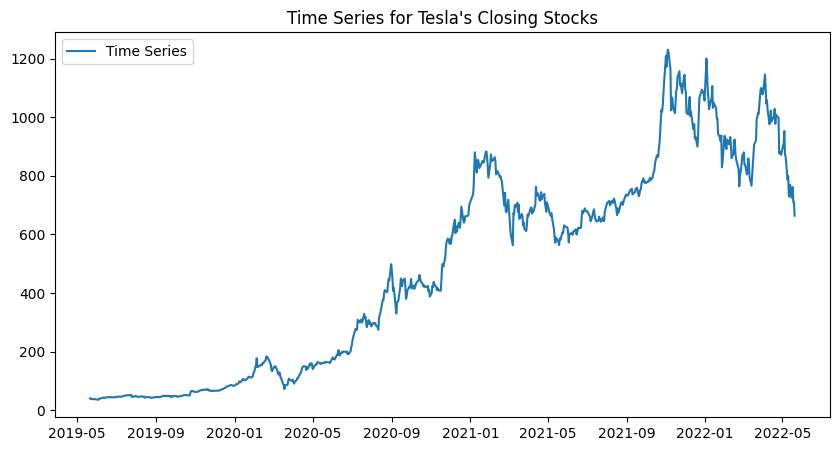

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(ts['Date'], ts['Close'], label='Time Series')
plt.legend()
plt.title("Time Series for Tesla's Closing Stocks")

<Figure size 1000x800 with 0 Axes>

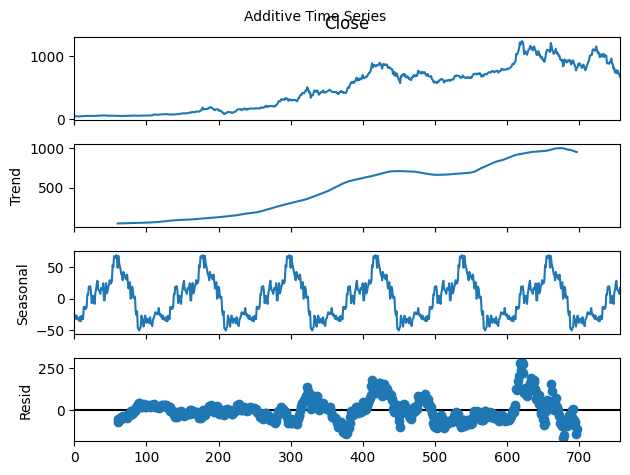

In [36]:
from statsmodels.tsa.seasonal import seasonal_decompose

additive = seasonal_decompose(ts['Close'], model='additive', period=120)
multiplicative = seasonal_decompose(ts['Close'], model='multiplicative', period=60)

plt.figure(figsize=(10,8))
additive.plot().suptitle('Additive Time Series', fontsize=10)
plt.show()

<Figure size 1000x800 with 0 Axes>

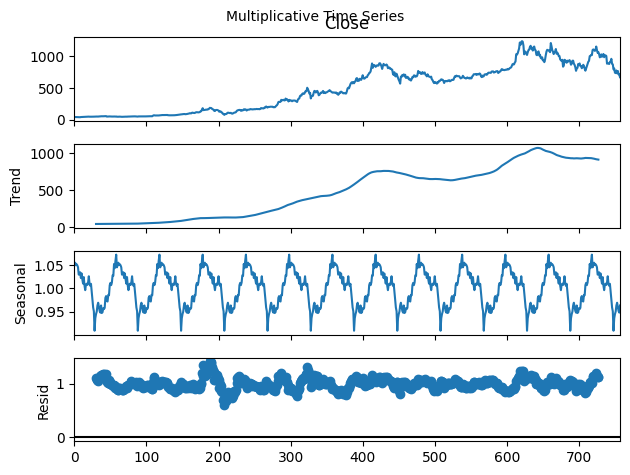

In [37]:
plt.figure(figsize=(10,8))
multiplicative.plot().suptitle('Multiplicative Time Series', fontsize=10)
plt.show()

In [38]:
trend = additive.trend
season = additive.seasonal
residual = additive.resid

Text(0.5, 1.0, "Trend for Tesla's Closing Stocks")

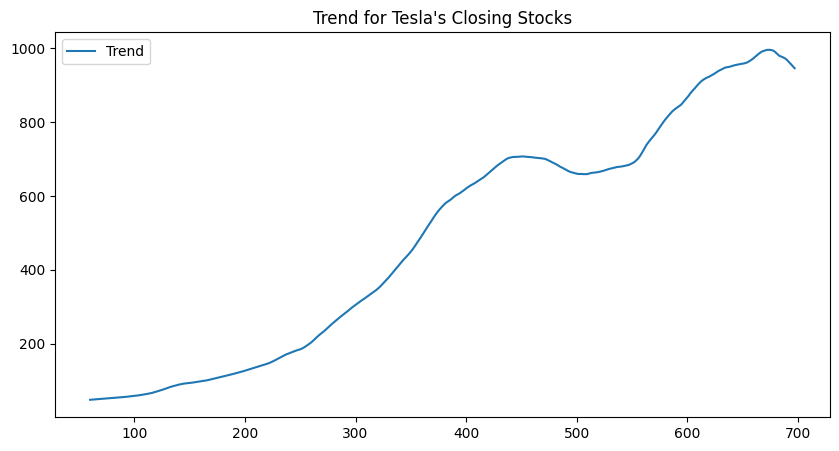

In [39]:
plt.figure(figsize=(10,5))
plt.plot(trend, label='Trend')
plt.legend()
plt.title("Trend for Tesla's Closing Stocks")

Text(0.5, 1.0, "season for Tesla's Closing Stocks")

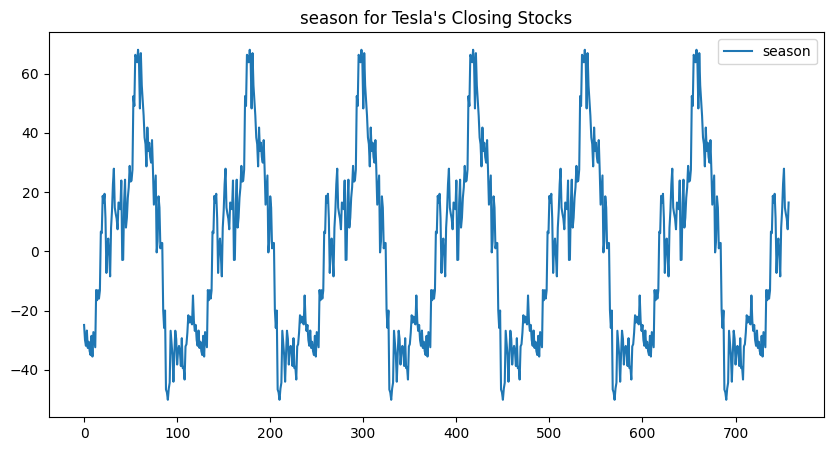

In [40]:
plt.figure(figsize=(10,5))
plt.plot(season, label='season')
plt.legend()
plt.title("season for Tesla's Closing Stocks")

Text(0.5, 1.0, "residual for Tesla's Closing Stocks")

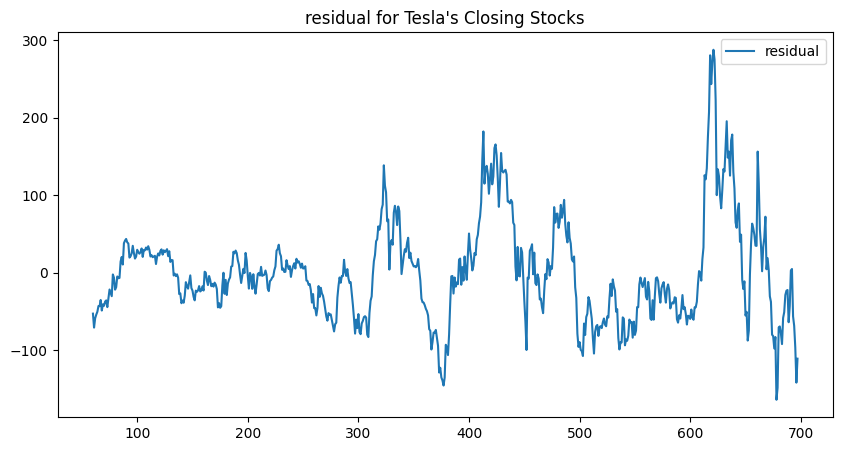

In [41]:
plt.figure(figsize=(10,5))
plt.plot(residual, label='residual')
plt.legend()
plt.title("residual for Tesla's Closing Stocks")

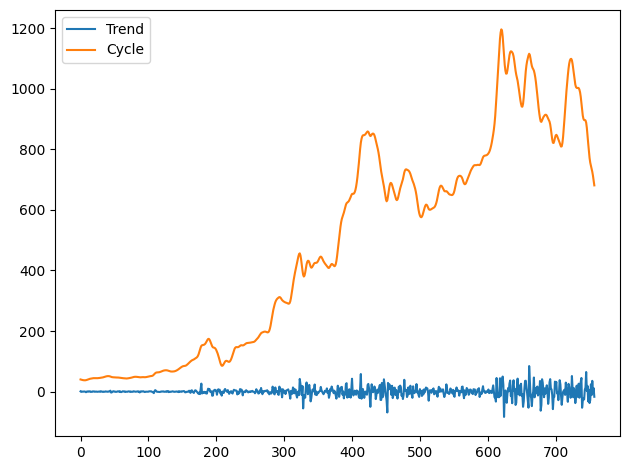

In [49]:
from statsmodels.tsa.filters.hp_filter import hpfilter

trend, cycle = hpfilter(ts['Close'], lamb=10)

plt.plot(trend, label='Trend')
plt.plot(cycle, label='Cycle')
plt.legend()
plt.tight_layout()
plt.show()